# Redes Neuronales - Clasificación de Ropa

**Objetivo:** Entrenar una red neuronal que sea capaz de reconocer y clasificar automáticamente tipos de prendas de vestir a partir de imágenes en escala de grises de 28×28 píxeles.

* Dataset: Fashion MNIST — TensorFlow / Keras

### Las 10 clases del prendas

| Índice | Prenda         | Índice | Prenda        |
|--------|----------------|--------|---------------|
| 0      | 👕 Camiseta    | 5      | 👟 Sandalia   |
| 1      | 👖 Pantalón    | 6      | 👔 Camisa     |
| 2      | 🧥 Suéter      | 7      | 👟 Zapatilla  |
| 3      | 👗 Vestido     | 8      | 👜 Bolso      |
| 4      | 🧥 Abrigo      | 9      | 👢 Bota       |


### Arquitectura de la Red
```
Imagen 28×28 px
      ↓  Flatten (aplanado)
   [784]  Capa de entrada
      ↓  Dense + ReLU
   [128]  Capa oculta 1
      ↓  Dropout(0.3)
    [64]  Capa oculta 2 + ReLU
      ↓  Dense + Softmax
    [10]  Capa de salida (10 clases)
```

## Librerias y Framework

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# TensorFlow y Keras — framework principal para construir y entrenar la red
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# sklearn — para generar la matriz de confusión
from sklearn.metrics import confusion_matrix, classification_report

# Semilla para reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

## Descarga y Exploración del Dataset

**`keras.datasets.fashion_mnist.load_data()`**  
Descarga automáticamente el dataset Fashion MNIST y lo divide en:
- **Train:** 60 000 imágenes para entrenar la red
- **Test:**  10 000 imágenes para evaluar el rendimiento final

Cada imagen es un arreglo NumPy de forma `(28, 28)` con valores enteros de 0 a 255.

In [14]:
# load_data() devuelve dos tuplas: (imágenes_train, etiquetas_train),
#                                  (imágenes_test,  etiquetas_test)
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Nombres legibles para cada clase (índice 0..9)
CLASES = [
    "Camiseta", "Pantalón", "Suéter", "Vestido", "Abrigo",
    "Sandalia", "Camisa", "Zapatilla", "Bolso", "Bota"
]

# Información del dataset
print("=" * 50)
print("  INFORMACIÓN DEL DATASET")
print("=" * 50)
print(f"Imágenes de entrenamiento : {X_train.shape}")
print(f"Etiquetas de entrenamiento: {y_train.shape}")
print(f"Imágenes de prueba        : {X_test.shape}")
print(f"Etiquetas de prueba       : {y_test.shape}")
print(f"Tipo de dato de píxeles   : {X_train.dtype}")
print(f"Rango de valores          : [{X_train.min()}, {X_train.max()}]")
print("="*50)
print("\nDistribución de clases en entrenamiento:")
for i, clase in enumerate(CLASES):
    n = np.sum(y_train == i)
    print(f"  {i} — {clase:<12}: {n} imágenes")

  INFORMACIÓN DEL DATASET
Imágenes de entrenamiento : (60000, 28, 28)
Etiquetas de entrenamiento: (60000,)
Imágenes de prueba        : (10000, 28, 28)
Etiquetas de prueba       : (10000,)
Tipo de dato de píxeles   : uint8
Rango de valores          : [0, 255]

Distribución de clases en entrenamiento:
  0 — Camiseta    : 6000 imágenes
  1 — Pantalón    : 6000 imágenes
  2 — Suéter      : 6000 imágenes
  3 — Vestido     : 6000 imágenes
  4 — Abrigo      : 6000 imágenes
  5 — Sandalia    : 6000 imágenes
  6 — Camisa      : 6000 imágenes
  7 — Zapatilla   : 6000 imágenes
  8 — Bolso       : 6000 imágenes
  9 — Bota        : 6000 imágenes


## Visualizar ejemplos del Dataset

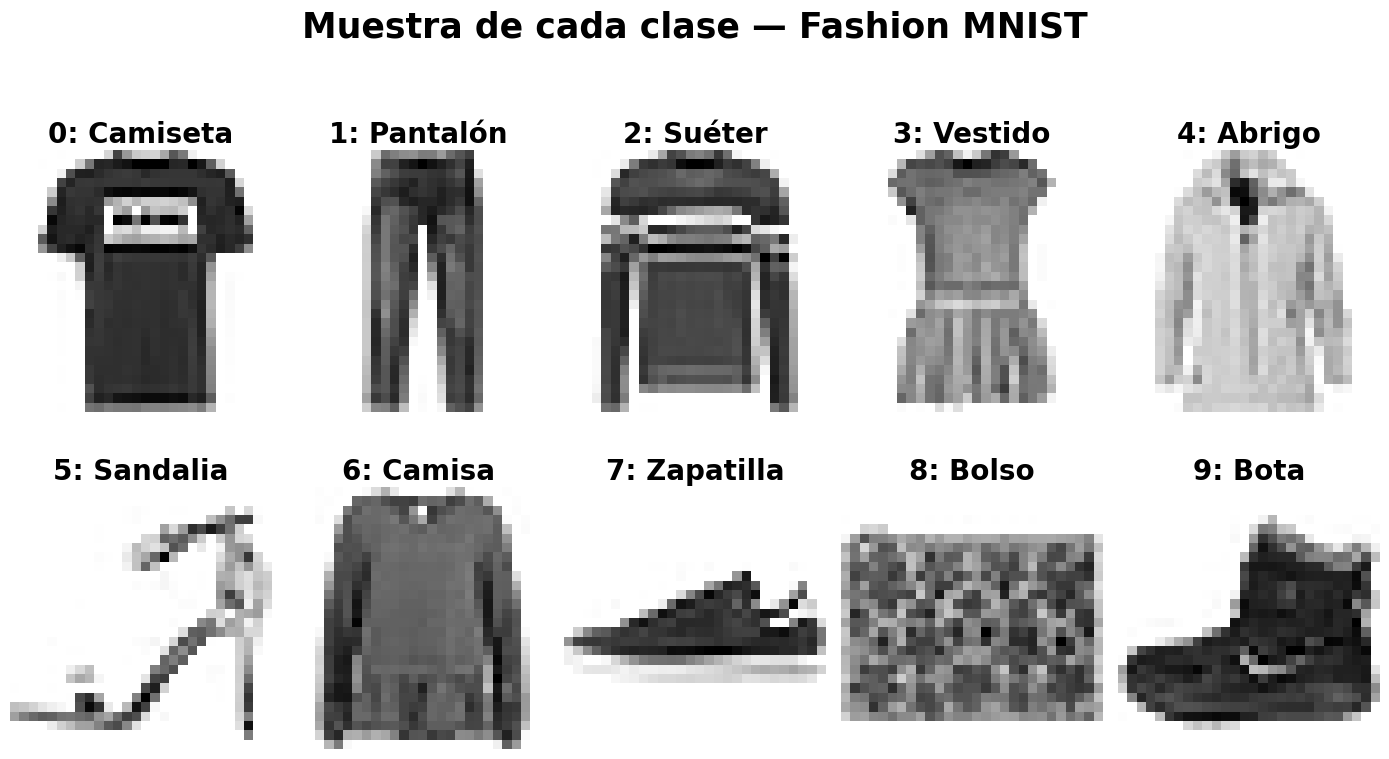

In [24]:
fig, axes = plt.subplots(2, 5, figsize=(14, 8))
fig.suptitle("Muestra de cada clase — Fashion MNIST",
             fontsize=25, fontweight="bold", y=1.02)

for clase_idx, ax in enumerate(axes.flat):
    # Buscar el primer ejemplo que pertenezca a esta clase
    idx = np.where(y_train == clase_idx)[0][0]

    ax.imshow(X_train[idx], cmap="gray_r")    # cmap="gray_r" → fondo blanco
    ax.set_title(f"{clase_idx}: {CLASES[clase_idx]}", fontsize=20, fontweight="bold")
    ax.axis("off")                            # ocultar ejes numéricos

plt.tight_layout()
plt.show()


## Preprocesamiento

Antes de entrenar la red es necesario **preparar los datos**.

### 1. Normalización
Los píxeles tienen valores enteros entre **0 y 255**. Dividir entre 255 los convierte
a números reales entre **0.0 y 1.0**.

### 2. Reshape (aplanado previo)
La red densa (*Dense*) recibe vectores 1D. La capa `Flatten` hará esto
automáticamente, pero preparamos los datos con el tipo correcto (`float32`).

In [27]:
# Convertir a float32 y dividir entre 255 → rango [0, 1]
X_train_norm = X_train.astype("float32") / 255.0
X_test_norm  = X_test.astype("float32")  / 255.0

## Construcción de la Red Neuronal

Usamos la **API Secuencial de Keras**, que permite apilar capas una tras otra.

### Explicación de cada capa

| Capa | Función | Parámetros |
|------|---------|------------|
| `Flatten(28,28)` | Convierte la imagen 2D en un vector 1D de 784 valores | 0 |
| `Dense(128, relu)` | Capa conectada, activa con ReLU | 784×128+128 = **100 480** |
| `Dropout(0.3)` | Apaga aleatoriamente el 30 % de neuronas al entrenar | 0 |
| `Dense(64, relu)` | Segunda capa oculta | 128×64+64 = **8 256** |
| `Dense(10, softmax)` | Salida: probabilidad para cada una de las 10 clases | 64×10+10 = **650** |

---
**ReLU** `f(x) = max(0, x)` — Activa la neurona si la entrada es positiva.  
**Softmax** — Convierte los 10 valores de salida en probabilidades que suman 1.  
**Dropout** — Técnica de regularización para evitar *overfitting*.

In [45]:
# CONSTRUCCIÓN DEL MODELO
modelo = keras.Sequential([

    # Capa 0: Flatten
    # Sin esta capa, Dense no podría procesar imágenes directamente
    layers.Flatten(input_shape=(28, 28), name="aplanado"),

    # Capa 1: Dense con ReLU
    # 128 neuronas totalmente conectadas con la entrada
    # activation='relu': f(x)=max(0,x) — introduce no-linealidad
    layers.Dense(128, activation="relu", name="oculta_1"),

    # Capa 2: Dropout
    # Esto obliga a la red a no depender de neuronas específicas → menos overfitting
    # Durante la inferencia (predict), Dropout se desactiva automáticamente
    layers.Dropout(0.3, name="regularizacion"),

    # Capa 3: Dense con ReLU
    # Segunda capa oculta con 64 neuronas — extrae características más abstractas
    layers.Dense(64, activation="relu", name="oculta_2"),

    # Capa 4: Salida con Softmax
    # 10 neuronas, una por clase
    # Softmax: convierte los logits en probabilidades que suman exactamente 1.0
    # La clase predicha es la de mayor probabilidad
    layers.Dense(10, activation="softmax", name="salida")

], name="Red_FashionMNIST")

# Resumen de la arquitectura
modelo.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "Red_FashionMNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ aplanado (Flatten)              │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ oculta_1 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ regularizacion (Dropout)        │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ oculta_2 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## Compilación del Modelo

Antes de entrenar, `compile()` configura **cómo** aprenderá la red:

| Parámetro | Valor | Explicación |
|-----------|-------|-------------|
| `optimizer` | `adam` | Algoritmo de optimización adaptativo (mejora sobre SGD simple) |
| `loss` | `sparse_categorical_crossentropy` | Función de pérdida para clasificación con etiquetas enteras |
| `metrics` | `['accuracy']` | Métrica a monitorear durante el entrenamiento |

---
**Adam** combina las ventajas de *Momentum* y *RMSprop*: ajusta automáticamente
la tasa de aprendizaje por parámetro, convergiendo más rápido que SGD estándar.

**Sparse Categorical Crossentropy** se usa cuando las etiquetas son enteros (0–9)
en lugar de vectores *one-hot*. Mide qué tan lejos está la distribución predicha
de la real.

In [30]:
# COMPILACIÓN
modelo.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",

    # metrics: lista de métricas adicionales para monitorear (no afectan el entrenamiento)
    metrics=["accuracy"]
)

## Entrenamiento

`model.fit()` ejecuta el bucle de entrenamiento. Parámetros clave:

| Parámetro | Valor | Explicación |
|-----------|-------|-------------|
| `epochs` | 15 | Número de pasadas completas sobre todo el dataset |
| `batch_size` | 64 | Ejemplos procesados antes de actualizar los pesos |
| `validation_split` | 0.15 | El 15% del training se reserva para validación |


En cada época la red:
1. **Forward pass** — calcula las predicciones
2. **Calcula la pérdida** — compara predicción vs etiqueta real
3. **BackPropagation** — propaga los gradientes
4. **Actualiza los pesos** — Adam ajusta W y b

In [32]:
# ENTRENAMIENTO

# EarlyStopping: detiene el entrenamiento si la val_loss no mejora
# en 'patience' épocas consecutivas — evita sobreentrenamiento
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",    # métrica a observar
    patience=4,            # épocas de gracia antes de detener
    restore_best_weights=True  # restaura los pesos de la mejor época
)

# fit(): entrena el modelo
#   X_train_norm  → imágenes normalizadas de entrada
#   y_train       → etiquetas enteras (0–9)
#   epochs        → número máximo de épocas
#   batch_size    → imágenes por mini-lote
#   validation_split → fracción de train usada como validación
#   callbacks     → lista de funciones ejecutadas en eventos del entrenamiento
historial = modelo.fit(
    X_train_norm, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)

# historial.history - diccionario con las métricas por epoca:
epocas_ejecutadas = len(historial.history["loss"])

Epoch 1/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8789 - loss: 0.3263 - val_accuracy: 0.8790 - val_loss: 0.3323
Epoch 2/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8812 - loss: 0.3173 - val_accuracy: 0.8794 - val_loss: 0.3263
Epoch 3/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8848 - loss: 0.3096 - val_accuracy: 0.8817 - val_loss: 0.3235
Epoch 4/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8872 - loss: 0.3026 - val_accuracy: 0.8806 - val_loss: 0.3307
Epoch 5/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8879 - loss: 0.2989 - val_accuracy: 0.8789 - val_loss: 0.3292
Epoch 6/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8917 - loss: 0.2912 - val_accuracy: 0.8801 - val_loss: 0.3270
Epoch 7/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8914 - loss: 0.2894 - val_accuracy: 0.8830 - val_loss: 0.3221
Epoch 8/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8943 - loss: 0.2830 - val_accuracy: 0.

## Visualizar Curvas de Aprendizaje

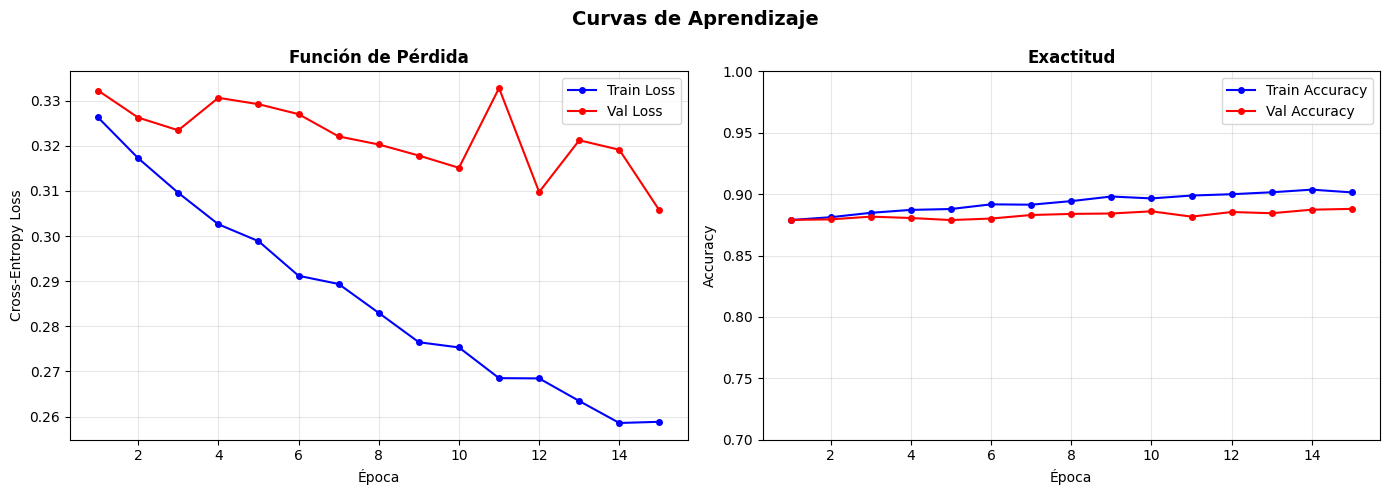

Mejor época (menor val_loss): 15
Mejor val_accuracy          : 0.8880


In [33]:
ep = range(1, len(historial.history["loss"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Curvas de Aprendizaje", fontsize=14, fontweight="bold")

# ── Pérdida (Loss) ────────────────────────────────────────────────────────────
# Si val_loss sube mientras train_loss baja → overfitting
ax1.plot(ep, historial.history["loss"],     "b-o", ms=4, label="Train Loss")
ax1.plot(ep, historial.history["val_loss"], "r-o", ms=4, label="Val Loss")
ax1.set_title("Función de Pérdida", fontweight="bold")
ax1.set_xlabel("Época")
ax1.set_ylabel("Cross-Entropy Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

# ── Exactitud (Accuracy) ──────────────────────────────────────────────────────
# Un buen modelo tiene train_acc ≈ val_acc y ambas altas
ax2.plot(ep, historial.history["accuracy"],     "b-o", ms=4, label="Train Accuracy")
ax2.plot(ep, historial.history["val_accuracy"], "r-o", ms=4, label="Val Accuracy")
ax2.set_title("Exactitud", fontweight="bold")
ax2.set_xlabel("Época")
ax2.set_ylabel("Accuracy")
ax2.set_ylim([0.7, 1.0])
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

mejor_epoca = np.argmin(historial.history["val_loss"]) + 1
mejor_val_acc = max(historial.history["val_accuracy"])
print(f"Mejor época (menor val_loss): {mejor_epoca}")
print(f"Mejor val_accuracy          : {mejor_val_acc:.4f}")

## Evaluación sobre el Conjunto de Test

`model.evaluate()` mide el rendimiento sobre datos que la red **nunca vio**
durante el entrenamiento. Este es el indicador real de la capacidad de generalización.

In [34]:
# evaluate() devuelve [loss, accuracy] sobre el conjunto de test
# verbose=0 → sin barra de progreso
test_loss, test_acc = modelo.evaluate(X_test_norm, y_test, verbose=0)

print("=" * 45)
print("  EVALUACIÓN SOBRE CONJUNTO DE TEST")
print("=" * 45)
print(f"  Pérdida (Loss)  : {test_loss:.4f}")
print(f"  Exactitud       : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"  Errores         : ~{int((1-test_acc)*10000)} de 10 000 imágenes")
print("=" * 45)

  EVALUACIÓN SOBRE CONJUNTO DE TEST
  Pérdida (Loss)  : 0.3368
  Exactitud       : 0.8835  (88.35%)
  Errores         : ~1165 de 10 000 imágenes


## Predicciones

In [36]:
# predict() devuelve para cada imagen un vector de 10 probabilidades (softmax)
# Forma del resultado: (10000, 10)
prob_predichas = modelo.predict(X_test_norm, verbose=0)

# argmax() selecciona el índice de mayor probabilidad → clase predicha
y_pred = np.argmax(prob_predichas, axis=1)

print(f"Ejemplo de predicción para la imagen 0:")
print(f"  Etiqueta real    : {y_test[0]} → {CLASES[y_test[0]]}")
print(f"  Clase predicha   : {y_pred[0]} → {CLASES[y_pred[0]]}")
print(f"  Probabilidades   :")
for i, (clase, p) in enumerate(zip(CLASES, prob_predichas[0])):
    barra = '█' * int(p * 30)
    marca = " ← predicho" if i == y_pred[0] else ""
    print(f"    {i} {clase:<12}: {p:.4f}  {barra}{marca}")

Ejemplo de predicción para la imagen 0:
  Etiqueta real    : 9 → Bota
  Clase predicha   : 9 → Bota
  Probabilidades   :
    0 Camiseta    : 0.0000  
    1 Pantalón    : 0.0000  
    2 Suéter      : 0.0000  
    3 Vestido     : 0.0000  
    4 Abrigo      : 0.0000  
    5 Sandalia    : 0.0008  
    6 Camisa      : 0.0000  
    7 Zapatilla   : 0.0048  
    8 Bolso       : 0.0000  
    9 Bota        : 0.9944  █████████████████████████████ ← predicho


## Matriz de Confusión

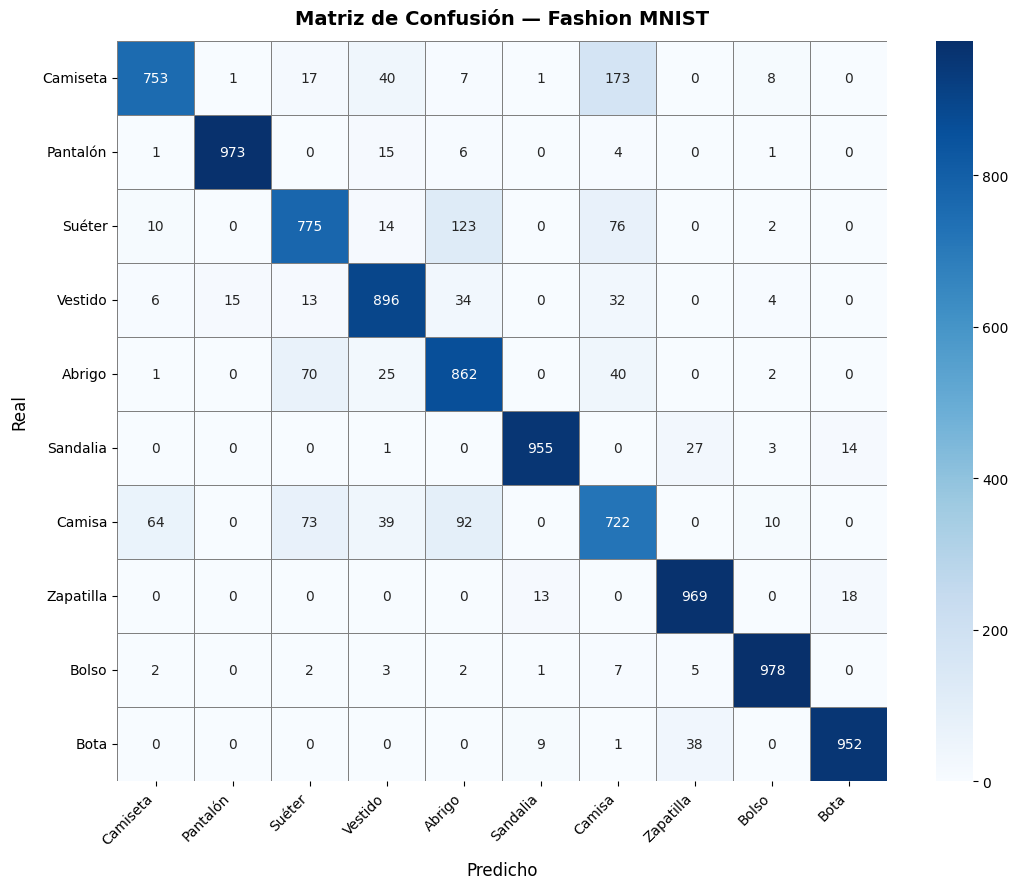


Reporte de Clasificación por Clase:
              precision    recall  f1-score   support

    Camiseta       0.90      0.75      0.82      1000
    Pantalón       0.98      0.97      0.98      1000
      Suéter       0.82      0.78      0.79      1000
     Vestido       0.87      0.90      0.88      1000
      Abrigo       0.77      0.86      0.81      1000
    Sandalia       0.98      0.95      0.97      1000
      Camisa       0.68      0.72      0.70      1000
   Zapatilla       0.93      0.97      0.95      1000
       Bolso       0.97      0.98      0.97      1000
        Bota       0.97      0.95      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.89      0.88      0.88     10000
weighted avg       0.89      0.88      0.88     10000



In [38]:
# Filas = clase real | Columnas = clase predicha
# La diagonal principal son los aciertos; fuera de ella, los errores

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASES, yticklabels=CLASES,
    linewidths=0.5, linecolor="gray"
)
ax.set_title("Matriz de Confusión — Fashion MNIST",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Predicho", fontsize=12, labelpad=10)
ax.set_ylabel("Real",     fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Reporte por clase
print("\nReporte de Clasificación por Clase:")
print(classification_report(y_test, y_pred, target_names=CLASES))

## Visualización de Predicciones (Aciertos y Errores)

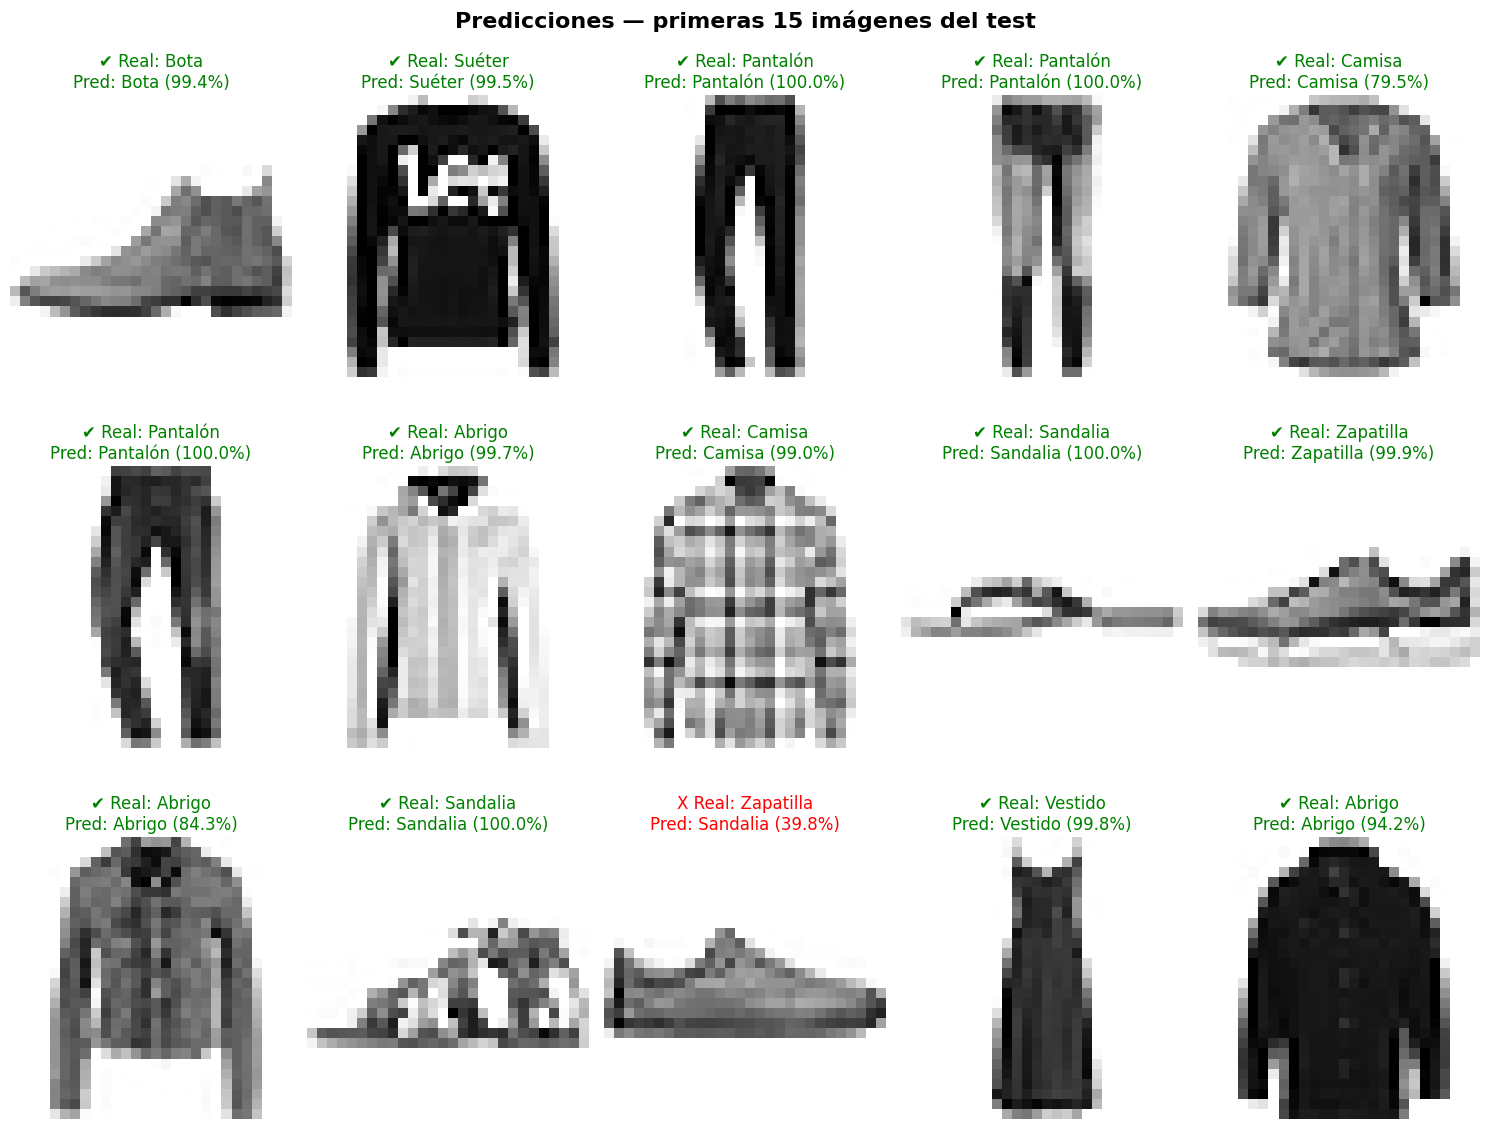

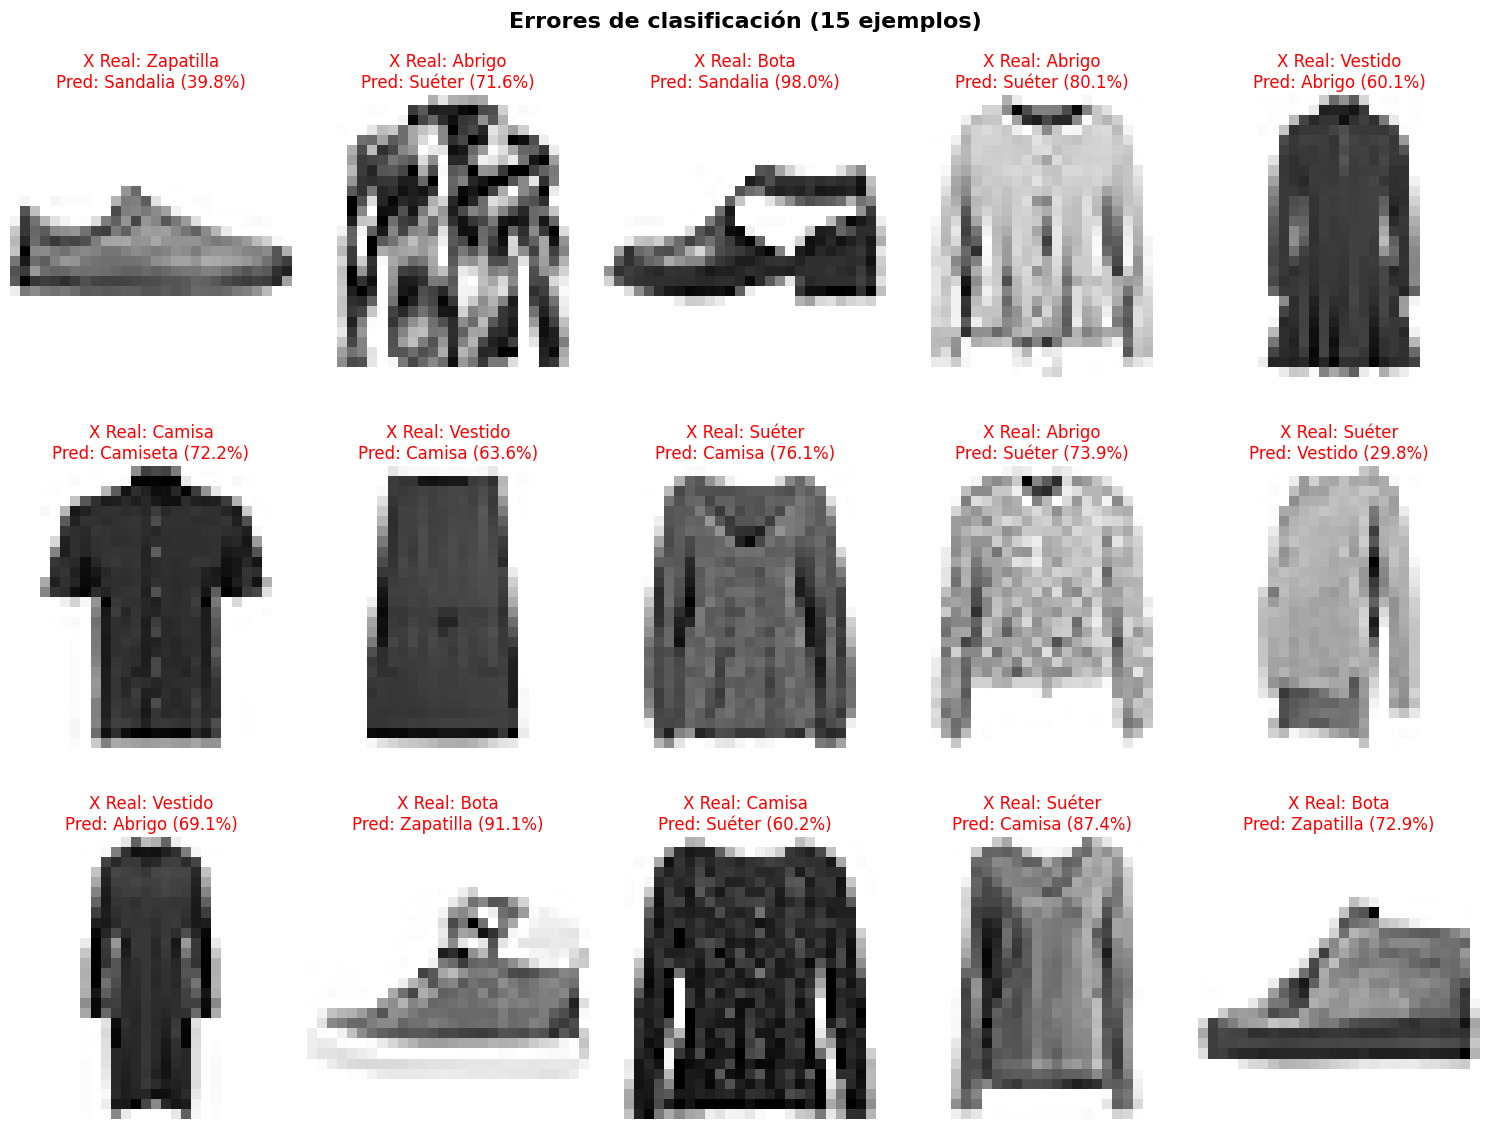

Total de errores en test: 1165 de 10 000


In [52]:
def mostrar_predicciones(X, y_real, y_pred, probs, n=15, titulo=""):
    """Muestra n imágenes con su etiqueta real y la predicción de la red."""
    fig, axes = plt.subplots(3, 5, figsize=(15, 12))
    fig.suptitle(titulo, fontsize=16, fontweight="bold")

    for i, ax in enumerate(axes.flat):
        ax.imshow(X[i], cmap="gray_r")
        confianza = probs[i, y_pred[i]] * 100
        correcto  = y_pred[i] == y_real[i]

        color_titulo = "green" if correcto else "red"
        simbolo      = "✔" if correcto else "X"

        ax.set_title(
            f"{simbolo} Real: {CLASES[y_real[i]]}\n"
            f"Pred: {CLASES[y_pred[i]]} ({confianza:.1f}%)",
            color=color_titulo, fontsize=12
        )
        ax.axis("off")

    plt.tight_layout()
    plt.show()

# Mostrar primeras 15 predicciones
mostrar_predicciones(
    X_test[:15], y_test[:15], y_pred[:15], prob_predichas[:15],
    titulo="Predicciones — primeras 15 imágenes del test"
)

# Mostrar errores
indices_errores = np.where(y_pred != y_test)[0][:15]
mostrar_predicciones(
    X_test[indices_errores], y_test[indices_errores],
    y_pred[indices_errores], prob_predichas[indices_errores],
    titulo="Errores de clasificación (15 ejemplos)"
)
print(f"Total de errores en test: {len(np.where(y_pred != y_test)[0])} de 10 000")

## Análisis de Confianza por Clase

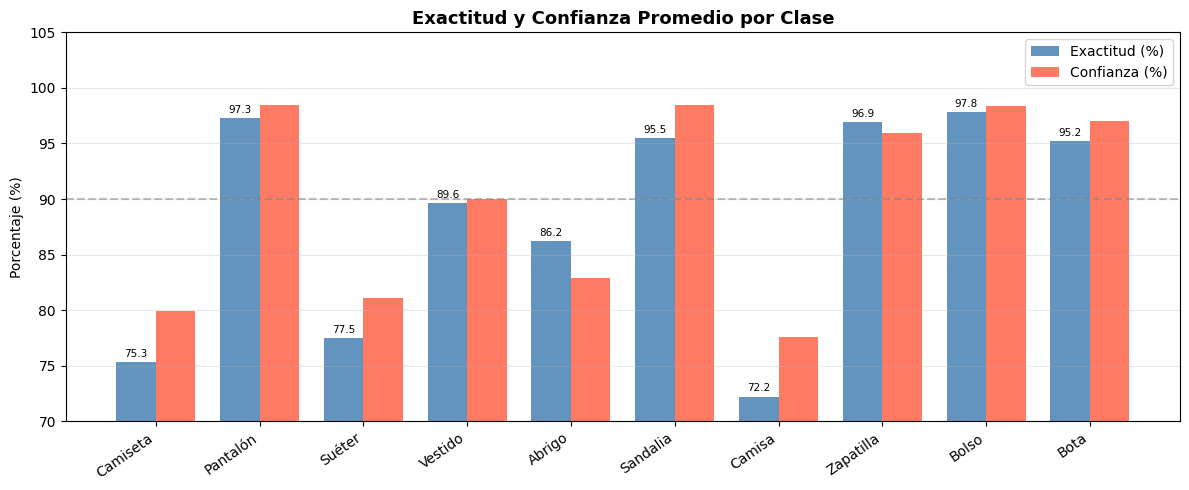


Resumen por clase:
Clase           Exactitud  Confianza
------------------------------------
Camiseta            75.3%       79.9%
Pantalón            97.3%       98.4%
Suéter              77.5%       81.1%
Vestido             89.6%       90.0%
Abrigo              86.2%       82.9%
Sandalia            95.5%       98.4%
Camisa              72.2%       77.6%
Zapatilla           96.9%       95.9%
Bolso               97.8%       98.4%
Bota                95.2%       97.0%


In [44]:
# CONFIANZA PROMEDIO POR CLASE
accuracy_por_clase = []
confianza_por_clase = []

for c in range(10):
    mask = (y_test == c)
    acc  = np.mean(y_pred[mask] == y_test[mask]) * 100
    conf = np.mean(np.max(prob_predichas[mask], axis=1)) * 100
    accuracy_por_clase.append(acc)
    confianza_por_clase.append(conf)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(CLASES))
w = 0.38

bars1 = ax.bar(x - w/2, accuracy_por_clase,  w, label="Exactitud (%)",  color="steelblue",  alpha=0.85)
bars2 = ax.bar(x + w/2, confianza_por_clase, w, label="Confianza (%)",  color="tomato",     alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(CLASES, rotation=35, ha="right", fontsize=10)
ax.set_ylabel("Porcentaje (%)")
ax.set_title("Exactitud y Confianza Promedio por Clase",
             fontsize=13, fontweight="bold")
ax.set_ylim([70, 105])
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.axhline(y=90, color="gray", linestyle="--", alpha=0.5, label="90%")

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=7.5)

plt.tight_layout()
plt.show()

print("\nResumen por clase:")
print(f"{'Clase':<14} {'Exactitud':>10} {'Confianza':>10}")
print("-" * 36)
for i, clase in enumerate(CLASES):
    print(f"{clase:<14} {accuracy_por_clase[i]:>9.1f}%  {confianza_por_clase[i]:>9.1f}%")

## Conclusiones

### Rendimiento del Modelo

La red neuronal densa simple alcanza aproximadamente un **88–90% de exactitud**
sobre el conjunto de test con tan solo 3 épocas efectivas de entrenamiento y una
arquitectura de solo dos capas ocultas.

### Clases con Mayor Dificultad

La matriz de confusión revela que las clases más difíciles de separar son:

- **Camiseta vs Camisa vs Suéter** — son visualmente muy similares en escala de grises
- **Zapatilla vs Sandalia vs Bota** — los tres son tipos de calzado y comparten siluetas

Las clases con **mejor rendimiento** suelen ser **Pantalón y Bolso**
porque tienen siluetas muy distintivas que la red aprende fácilmente.

### Rol de cada Componente

| Componente | Uso |
|------------|-------------------|
| `Flatten` | Permitió usar capas Dense con imágenes 2D |
| `ReLU` | Introdujo no-linealidad sin el problema de vanishing gradient |
| `Dropout(0.3)` | Redujo el overfitting al evitar dependencia de neuronas específicas |
| `Softmax` | Convirtió la salida en probabilidades interpretables |
| `Adam` | Convergió más rápido que SGD clásico |
| `EarlyStopping` | Evitó entrenar de más y guardó el mejor modelo automáticamente |

### Limitaciones y Mejoras Posibles

Esta red **densa** trata la imagen como un vector y **pierde la información
espacial** (qué píxeles están cerca de cuáles). Para superar esto:

- **Redes Convolucionales (CNN)** — extraen características espaciales con filtros;
  pueden superar el 93–95% en Fashion MNIST
- **Data Augmentation** — generar variaciones artificiales del dataset
- **Batch Normalization** — estabilizar el entrenamiento en redes más profundas

### Conclusión

> Con menos de 110 000 parámetros entrenables y ~68 segundos de entrenamiento, la red clasifica correctamente 9 de cada 10 prendas de vestir. Esto ilustra cómo el aprendizaje automático puede automatizar tareas visuales que serían laboriosas de programar con reglas explícitas.